Installing required packages and imported 

In [25]:
pip install numpy dual_quaternions scipy tensorflow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 38.7 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 54.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 68.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from dual_quaternions import DualQuaternion as DQ
import scipy as sp
from scipy.linalg import expm

D-H Parameters of UR5, 6-revolute(6R), Reach:~850mm, Payload: 5Kg, All measurements in Metric (M/mm).

ai-1 alpi-1 di thetai
1 0 0 127.3
2 0 -pi/2 0
3 -425.0 0 0
4 -392.25 0 109.15
5 0 pi/2 94.65
6 0 -pi/2 82.3

In [3]:

a = np.array([0.0,0.0,-0.42500,-0.39225,0.0,0.0])
alpha = np.array([0.0,-(np.pi/2),0.0,0.0,(np.pi/2),-(np.pi/2)])
d = np.array([0.1273,0.0,0.0,0.10915,0.09465,0.0823])
theta = np.array([0.0,0.0,0.0,0.0,0.0,0.0])
dh = np.array([a,
               alpha,
               d,
               theta])
print(dh)

[[ 0.          0.         -0.425      -0.39225     0.          0.        ]
 [ 0.         -1.57079633  0.          0.          1.57079633 -1.57079633]
 [ 0.1273      0.          0.          0.10915     0.09465     0.0823    ]
 [ 0.          0.          0.          0.          0.          0.        ]]


| Parameter  | Meaning                 |
| ---------- | ----------------------- |
| (a_i)      | Link length along (x_i) |
| (\alpha_i) | Link twist about (x_i)  |
| (d_i)      | Link offset along (z_i) |
| (\theta_i) | Joint angle about (z_i) |


In [4]:
def dh_matrix(a, alpha, d, theta):
    """Create 4x4 transformation matrix from DH parameters"""
    ct = np.cos(theta)
    st = np.sin(theta)
    ca = np.cos(alpha)
    sa = np.sin(alpha)
    return np.array([
        [ct, -st*ca, st*sa, a*ct],
        [st, ct*ca, -ct*sa, a*st],
        [0, sa, ca, d],
        [0, 0, 0, 1]
    ])

# Compute M by multiplying all Ai at home position
M = np.eye(4)
for i in range(6):
    Ai = dh_matrix(a[i], alpha[i], d[i], theta[i])
    M = M @ Ai  # multiply sequentially

print("Home configuration M:\n", M)

Home configuration M:
 [[ 1.000000e+00  0.000000e+00  0.000000e+00 -8.172500e-01]
 [ 0.000000e+00  6.123234e-17  1.000000e+00  2.038000e-01]
 [ 0.000000e+00 -1.000000e+00  6.123234e-17  2.096000e-01]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]


Building Joint axis in world/Space frame/Screw axis

Joint axis direction at zero config:

Joint 1: rotates about Z-axis of base
w1 = [0,0,1]
Joint 2: rotates about Y-axis (after alpha1 = -pi/2 rotation about X)
w2 = [0,1,0]
Joint 3: rotates about Y-axis (same as joint 2 in zero config)
w3 = [0,1,0]
Joint 4: rotates about Y-axis
w4 = [0,1,0]
Joint 5: rotates about Z-axis (after alpha 4 = pi/2)
w5 = [0,0,-1]
Joint 6: rotates about Y-axis (after alpha 5 = -pi/2)
w6 = [0,1,0]

In [5]:
w1 = np.array([0.,0.,1.])
w2 = np.array([0.,1.,0.])
w3 = np.array([0.,1.,0.])
w4 = np.array([0.,1.,0.])
w5 = np.array([0.,0.,-1.])
w6 = np.array([0.,1.,0.])
wn = np.array([w1,
               w2,
               w3,
               w4,
               w5,
               w6])
print(wn)

[[ 0.  0.  1.]
 [ 0.  1.  0.]
 [ 0.  1.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -1.]
 [ 0.  1.  0.]]


Point on each joint axis at Zero Config (origin of each joint):

joint 1 at base origin
q1 = [0,0,0]
Joint 2 lifted by d1
q2 = [0,0,0.1273]
Joint 3 (a2 = d along world x at zero config)
q3 = [-0.425,0,0.1273]
Joint 4 (d4 is along the Z-axis of frame 3, which at zero point in world Z
q4 = [-0.425 + (-0.39225),0,0.1273+d4.(0)]
   =[-0.81725,0,0.22195]
Joint 5 ( q4 + d5 along frame-4 Z-axis frame 4 Z-axis at zero = world Z
q5 = [-0.81725,0,0.1273+0.09465]
   = [-0.81725,0,0.22195]
joint 6 (q5 + 0 displacment, d6 along frame-5 Z)
frame 5 Z = world Y ( because alph 4 = pi/2 flipped Z into Y)
= [ -0.81725, d6, 0.22195]
q6 = [-0.81725,0.19145,0.00550]
same as end effector at zero

In [6]:
q1 = np.array([0.,0.,0.])
q2 = np.array([0.,0.,0.1273])
q3 = np.array([-0.425,0.,0.1273])
q4 = np.array([-0.81725,0.,0.1273])
q5 = np.array([-0.81725,0.,0.22195])
q6 = np.array([-0.81725,0.19145,0.00550])
qn = np.array([q1,
               q2,
               q3,
               q4,
               q5,
               q6])
print(qn)

[[ 0.       0.       0.     ]
 [ 0.       0.       0.1273 ]
 [-0.425    0.       0.1273 ]
 [-0.81725  0.       0.1273 ]
 [-0.81725  0.       0.22195]
 [-0.81725  0.19145  0.0055 ]]


Space Screw Axes Si = [wi;-wi x qi]
The linear velocity components is V = -wi x q (or equivalently q x w)

Si: wi = [0,0,1], qi = [0,0,0]
vi = -wi x qi  = -[0,0,1] x [0,0,0] = [0,0,0]
si = [0,0,1,0,0,0]

Taken s1,w1,q1 for example

In [7]:
v1 = np.cross(-w1, q1)
print(v1)
s1 = np.concatenate((w1, v1))
print(s1)

[0. 0. 0.]
[0. 0. 1. 0. 0. 0.]


In [8]:
v2 = np.cross(-w2, q2)
print(v2)
s2 = np.concatenate((w2, v2))
print(s2)

[-0.1273  0.      0.    ]
[ 0.      1.      0.     -0.1273  0.      0.    ]


In [9]:
v3 = np.cross(-w3, q3)
print(v3)
s3 = np.concatenate((w3, v3))
print(s3)

[-0.1273  0.     -0.425 ]
[ 0.      1.      0.     -0.1273  0.     -0.425 ]


In [10]:
v4 = np.cross(-w4, q4)
print(v4)
s4 = np.concatenate((w4, v4))
print(s4)

[-0.1273   0.      -0.81725]
[ 0.       1.       0.      -0.1273   0.      -0.81725]


In [11]:
v5 = np.cross(-w5, q5)
print(v5)
s5 = np.concatenate((w5, v5))
print(s5)

[-0.      -0.81725 -0.     ]
[ 0.       0.      -1.      -0.      -0.81725 -0.     ]


In [12]:
v6 = np.cross(-w6, q6)
print(v6)
s6 = np.concatenate((w6, v6))
print(s6)

[-0.0055   0.      -0.81725]
[ 0.       1.       0.      -0.0055   0.      -0.81725]


In [13]:
sn = np.array([s1,
s2,
s3,
s4,
s5,
s6])
print(sn)

[[ 0.       0.       1.       0.       0.       0.     ]
 [ 0.       1.       0.      -0.1273   0.       0.     ]
 [ 0.       1.       0.      -0.1273   0.      -0.425  ]
 [ 0.       1.       0.      -0.1273   0.      -0.81725]
 [ 0.       0.      -1.      -0.      -0.81725 -0.     ]
 [ 0.       1.       0.      -0.0055   0.      -0.81725]]


# Step 1: Define the 6D screw axis

A screw axis is written as:

S = [ωx, ωy, ωz, vx, vy, vz]

Where:
- ω = angular velocity part
- v = linear velocity part

# Step 2: Split into ω and v

Separate the 6D vector:

ω = [ωx, ωy, ωz]
v = [vx, vy, vz]

# Step 3: Construct the skew-symmetric matrix [ω]×

The angular velocity is converted into a matrix:

[ω]× =
[[ 0   -ωz   ωy ]
 [ ωz   0   -ωx ]
 [-ωy  ωx    0  ]]

 # Step 4: Build the se(3) matrix structure

The 4×4 matrix form is:

[S] =
[[ [ω]×   v ]
 [  0     0 ]]

 # Step 5: Expanded 4×4 form

[S] =
[[ 0   -ωz   ωy   vx ]
 [ ωz   0   -ωx   vy ]
 [-ωy  ωx    0    vz ]
 [ 0    0    0     0 ]] 

 # Step 6: Example screw axis

Given:

S = [0, 0, 1, 0, 0, 0]

Then:
ω = [0, 0, 1]
v = [0, 0, 0]

# Step 7: Compute skew-symmetric matrix

[ω]× =
[[ 0  -1   0 ]
 [ 1   0   0 ]
 [ 0   0   0 ]]

 # Step 8: Final se(3) matrix

[S] =
[[ 0  -1   0   0 ]
 [ 1   0   0   0 ]
 [ 0   0   0   0 ]
 [ 0   0   0   0 ]]

 # Step 9: Python implementation
def skew(w):
    return np.array([
        [0, -w[2], w[1]],
        [w[2], 0, -w[0]],
        [-w[1], w[0], 0]
    ])

S = [0, 0, 1, 0, 0, 0]

omega = np.array(S[:3])
v = np.array(S[3:])

se3 = np.zeros((4, 4))
se3[:3, :3] = skew(omega)
se3[:3, 3] = v

print(se3)

In [14]:
def skew(w):
    return np.array([
        [0, -w[2], w[1]],
        [w[2], 0, -w[0]],
        [-w[1], w[0], 0]
    ])

def d6_se3(s):
    S = s

    omega = np.array(S[:3])
    v = np.array(S[3:])

    se3 = np.zeros((4, 4))
    se3[:3, :3] = skew(omega)
    se3[:3, 3] = v
    return se3

se1 = d6_se3(s1)
se2 = d6_se3(s2)
se3 = d6_se3(s3)
se4 = d6_se3(s4)
se5 = d6_se3(s5)
se6 = d6_se3(s6)
sen = np.array([se1,
                se2,
                se3,
                se4,
                se5,
                se6])
print(sen)

[[[ 0.      -1.       0.       0.     ]
  [ 1.       0.      -0.       0.     ]
  [-0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]]

 [[ 0.      -0.       1.      -0.1273 ]
  [ 0.       0.      -0.       0.     ]
  [-1.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]]

 [[ 0.      -0.       1.      -0.1273 ]
  [ 0.       0.      -0.       0.     ]
  [-1.       0.       0.      -0.425  ]
  [ 0.       0.       0.       0.     ]]

 [[ 0.      -0.       1.      -0.1273 ]
  [ 0.       0.      -0.       0.     ]
  [-1.       0.       0.      -0.81725]
  [ 0.       0.       0.       0.     ]]

 [[ 0.       1.       0.      -0.     ]
  [-1.       0.      -0.      -0.81725]
  [-0.       0.       0.      -0.     ]
  [ 0.       0.       0.       0.     ]]

 [[ 0.      -0.       1.      -0.0055 ]
  [ 0.       0.      -0.       0.     ]
  [-1.       0.       0.      -0.81725]
  [ 0.       0.       0.       0.     ]]]


Matrix Exponentials Computing e^([S] Theta)

In [15]:
es1 = expm(se1 * theta[0])
print(es1)


[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [16]:
def expo_s(sen, theta):
    esn = []  # create empty list outside the loop
    for se_i, th_i in zip(sen, theta):
        #print(se_i, th_i)
        esn.append(expm(se_i * th_i))  # append each exp([S_i]*θ_i)
    return esn  # return the list of matrices

# Example usage
exn = np.array(expo_s(sen, theta))
print(exn)

[[[1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]]

 [[1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]]

 [[1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]]

 [[1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]]

 [[1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]]

 [[1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]]]


Forward kinematics by POE (Product of exponents)

In [17]:
def forward_kinematics(sen, theta, M):
    """
    sen: list of 4x4 se(3) matrices ([S1], [S2], ...)
    theta: list of joint angles
    M: 4x4 home configuration matrix
    """
    T = np.eye(4)  # start with identity matrix
    for se_i, th_i in zip(sen, theta):
        T = T @ expm(se_i * th_i)  # multiply exponentials
    T = T @ M  # multiply by home configuration at the end
    return T

In [18]:
# sen = [se1, se2, se3, ...]  # list of 4x4 se(3)
# theta = [0.1, 0.2, -0.3, ...]  # joint angles

T_final = forward_kinematics(sen, theta, M)
print("Final Transformation T:\n", T_final)

Final Transformation T:
 [[ 1.000000e+00  0.000000e+00  0.000000e+00 -8.172500e-01]
 [ 0.000000e+00  6.123234e-17  1.000000e+00  2.038000e-01]
 [ 0.000000e+00 -1.000000e+00  6.123234e-17  2.096000e-01]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]


Srew axis to Dual Quaternion

In [19]:
def screw_dq(sen, theta):
    dual_quats = []
    sen = np.array(sen, dtype=float)  # ensure it's a numpy array of floats

    for i in range(sen.shape[0]):
        S = sen[i]  # 6D screw axis
        th = float(theta[i])

        # Extract rotation axis
        omega = np.array(S[:3], dtype=float).flatten()  # ensure 1D array
        if np.linalg.norm(omega) == 0:
            l = np.array([0.0, 0.0, 0.0], dtype=float)
        else:
            l = (omega / np.linalg.norm(omega)).astype(float)  # normalize

        # Extract moment
        m = np.array(S[3:], dtype=float).flatten()
        if m.size != 3:
            raise ValueError(f"Screw axis moment must have 3 elements, got {m.size}")
        m = m.astype(float)

        d = 0.0  # revolute joint

        # Use your DualQuaternion class
        dq = DQ.from_screw(l=l.tolist(), m=m.tolist(), theta=float(th), d=float(d))
        dual_quats.append(dq)

    return dual_quats

# Example usage:
# sen = list/array of 6D screw axes
# theta = joint angles
print("sn.shape =", sn.shape)
for i, S in enumerate(sn):
    print(f"Joint {i}: length = {len(S)}")

dqn = screw_dq(sn, theta)
dqm = DQ.from_homogeneous_matrix(M)
# Print each dual quaternion
for i, dq in enumerate(dqn):
    print(f"Joint {i} dual quaternion:\n", dq)

print(f"M dual quaternion:\n",dqm)

sn.shape = (6, 6)
Joint 0: length = 6
Joint 1: length = 6
Joint 2: length = 6
Joint 3: length = 6
Joint 4: length = 6
Joint 5: length = 6
Joint 0 dual quaternion:
 rotation: Quaternion(np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)), translation: Quaternion(np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)), 
translation vector: [np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Joint 1 dual quaternion:
 rotation: Quaternion(np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)), translation: Quaternion(np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)), 
translation vector: [np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Joint 2 dual quaternion:
 rotation: Quaternion(np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)), translation: Quaternion(np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)), 
translation vector: [np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Joint 3 dual qua

Forward Kinematics
screw_dq generating the dual quaternions for each joint, and dqm as the home pose dual quaternion from your matrix M. Now, to compute forward kinematics using the Product of Exponentials, we just multiply all the joint dual quaternions together, then multiply by the home pose.

In [20]:
def dq_fk(sn, theta):
    """
    Forward kinematics: return end-effector dual quaternion
    """
    dqn = screw_dq(sn, theta)
    dqm = DQ.from_homogeneous_matrix(M)
    
    dq_ee = DQ.identity()
    for dq in dqn:
        dq_ee = dq_ee * dq
    dq_ee = dq_ee * dqm
    return dq_ee

# Print result
print("End-effector dual quaternion:")
print(dq_fk(sn, theta))

End-effector dual quaternion:


rotation: Quaternion(np.float64(0.7071067811865475), np.float64(-0.7071067811865475), np.float64(0.0), np.float64(0.0)), translation: Quaternion(np.float64(-0.28894150846235295), np.float64(-0.28894150846235295), np.float64(-0.002050609665440989), np.float64(0.14615897167125935)), 
translation vector: [np.float64(-0.8172499999999998), np.float64(0.20379999999999993), np.float64(0.20959999999999995)]


Inverss Kinematics using screw axis, Duel quaternions and numerical method

In [21]:
def dq_error(dq_current, dq_target):
    """
    Compute 6D error (rotation + translation) between two dual quaternions.
    Returns 6x1 vector: [rotation_error(3), translation_error(3)]
    """
    # dq_array: [q_rw, q_rx, q_ry, q_rz, q_tx, q_ty, q_tz]
    curr = dq_current.dq_array()
    targ = dq_target.dq_array()
    
    # Rotation error using quaternion multiplication: q_rel = q_target * q_current^-1
    # Quaternion inverse for unit quaternion: q^-1 = [w, -x, -y, -z]
    w1, x1, y1, z1 = curr[:4]
    w2, x2, y2, z2 = targ[:4]
    
    # Relative rotation quaternion q_rel = q_target * q_current^-1
    w_rel = w2*w1 + x2*x1 + y2*y1 + z2*z1
    x_rel = w2*(-x1) + x2*w1 + y2*(-z1) - z2*(-y1)
    y_rel = w2*(-y1) - x2*(-z1) + y2*w1 + z2*(-x1)
    z_rel = w2*(-z1) + x2*(-y1) - y2*(-x1) + z2*w1
    
    # Small-angle approximation: rotation vector = 2 * vector part
    e_rot = 2 * np.array([x_rel, y_rel, z_rel])  # keep factor 2 for rotation
    
    # Translation error: simple difference (factor 1, no 2)
    t_curr = np.array(curr[4:7])
    t_targ = np.array(targ[4:7])
    e_trans = t_targ - t_curr
    
    e = np.hstack((e_rot, e_trans))
    return e  # 6x1

def jacobian_dual_q(sn, theta, delta=1e-6):
    """
    Numerical Jacobian of dual quaternion FK wrt theta
    """
    n = len(theta)
    J = np.zeros((6, n))
    
    dq_current = dq_fk(sn, theta)  # function returning end-effector DQ
    
    for i in range(n):
        theta_perturb = theta.copy()
        theta_perturb[i] += delta
        dq_perturb = dq_fk(sn, theta_perturb)
        e = dq_error(dq_current, dq_perturb)
        J[:, i] = e / delta
        
    return J

def inverse_kinematics(sn, M_target, theta_init, tol=1e-6, max_iter=200):
    """
    Numerical IK using dual quaternions
    """
    theta = np.array(theta_init, dtype=float)
    dq_target = DQ.from_homogeneous_matrix(M_target)
    
    for k in range(max_iter):
        dq_curr = dq_fk(sn, theta)
        e = dq_error(dq_curr, dq_target)
        
        if np.linalg.norm(e) < tol:
            print(f"Converged in {k} iterations")
            return theta
        
        J = jacobian_dual_q(sn, theta)
        dtheta = np.linalg.pinv(J) @ e
        theta += dtheta
        
    print("IK did not converge")
    return theta


theta_init = theta        # initial guess
M_target = M                    # 4x4 target homogeneous pose

theta_sol = inverse_kinematics(sn, M_target, theta_init)
print("Solved joint angles:", theta_sol)

Converged in 0 iterations
Solved joint angles: [0. 0. 0. 0. 0. 0.]


In [22]:
def dq_to_homogeneous(dq):
    """Convert dual quaternion to 4x4 homogeneous matrix"""
    arr = dq.dq_array()
    w, x, y, z = arr[:4]
    R = np.array([
        [1 - 2*(y**2 + z**2), 2*(x*y - z*w), 2*(x*z + y*w)],
        [2*(x*y + z*w), 1 - 2*(x**2 + z**2), 2*(y*z - x*w)],
        [2*(x*z - y*w), 2*(y*z + x*w), 1 - 2*(x**2 + y**2)]
    ])
    t = np.array(arr[4:7])
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = t
    return T

def pose_error(M_target, M_sol):
    """Compute rotation (rad) and translation (m) error between two 4x4 matrices"""
    R_diff = M_target[:3, :3].T @ M_sol[:3, :3]
    angle_error = np.arccos(np.clip((np.trace(R_diff) - 1)/2, -1.0, 1.0))
    trans_error = np.linalg.norm(M_target[:3, 3] - M_sol[:3, 3])
    return angle_error, trans_error

def test_fk_ik_ur5(sn, dq_fk_func, joint_limits, n_tests=5, elbow='up'):
    """
    FK→IK→FK test for UR5 with branch selection.
    
    Parameters:
        sn: screw axes
        dq_fk_func: FK function returning DualQuaternion
        joint_limits: list of (min,max) in radians
        n_tests: number of random tests
        elbow: 'up' or 'down'
    """
    n_joints = sn.shape[0]
    results = []

    for test in range(n_tests):
        res = {}
        # Generate random joint angles within limits
        theta_random = np.array([np.random.uniform(low, high) for (low, high) in joint_limits])
        # FK → get target pose
        dq_target = dq_fk_func(sn, theta_random)
        M_target = dq_to_homogeneous(dq_target)
        # IK with initial guess = original joint angles
        theta_guess = np.copy(theta_random)
        # TODO: implement elbow-up/down selection in IK if needed
        theta_sol = inverse_kinematics(sn, M_target, theta_guess)
        # FK of IK solution
        dq_sol = dq_fk_func(sn, theta_sol)
        M_sol = dq_to_homogeneous(dq_sol)
        angle_err, trans_err = pose_error(M_target, M_sol)
        joint_err = np.linalg.norm(theta_random - theta_sol)

        res['fkik'] = {
            'theta_original': theta_random,
            'theta_sol': theta_sol,
            'rotation_error_rad': angle_err,
            'translation_error_m': trans_err,
            'joint_error_rad': joint_err
        }

        # IK → FK → IK
        # Random target pose
        theta_random2 = np.array([np.random.uniform(low, high) for (low, high) in joint_limits])
        dq_target2 = dq_fk_func(sn, theta_random2)
        M_target2 = dq_to_homogeneous(dq_target2)
        theta_sol2 = inverse_kinematics(sn, M_target2, np.copy(theta_random2))
        dq_sol2 = dq_fk_func(sn, theta_sol2)
        M_sol2 = dq_to_homogeneous(dq_sol2)
        theta_recovered = inverse_kinematics(sn, M_sol2, np.copy(theta_sol2))
        angle_err2, trans_err2 = pose_error(M_target2, M_sol2)
        joint_err2 = np.linalg.norm(theta_sol2 - theta_recovered)

        res['ikfkik'] = {
            'theta_original': theta_sol2,
            'theta_recovered': theta_recovered,
            'rotation_error_rad': angle_err2,
            'translation_error_m': trans_err2,
            'joint_error_rad': joint_err2
        }

        results.append(res)

        print(f"\nTest {test+1}:")
        print("FK → IK → FK errors:")
        print(f"Rotation error (rad): {angle_err:.4f}, Translation error (m): {trans_err:.44f}, Joint error (rad): {joint_err:.4f}")
        print("IK → FK → IK errors:")
        print(f"Rotation error (rad): {angle_err2:.4f}, Translation error (m): {trans_err2:.4f}, Joint error (rad): {joint_err2:.4f}")

    return results

# UR5 joint limits
ur5_limits = [
    (-2*np.pi/3, 2*np.pi/3),  # θ1
    (-np.pi, np.pi),          # θ2
    (-2*np.pi/3, 2*np.pi/3),  # θ3
    (-2*np.pi, 2*np.pi),      # θ4
    (-2*np.pi, 2*np.pi),      # θ5
    (-2*np.pi, 2*np.pi)       # θ6
]

# Example test: elbow-up
results = test_fk_ik_ur5(sn, dq_fk, joint_limits=ur5_limits, n_tests=3, elbow='up')

Converged in 8 iterations
Converged in 123 iterations
Converged in 4 iterations

Test 1:
FK → IK → FK errors:
Rotation error (rad): 0.0000, Translation error (m): 0.34498631416442882002826308962539769709110260, Joint error (rad): 179.6908
IK → FK → IK errors:
Rotation error (rad): 0.0000, Translation error (m): 0.3096, Joint error (rad): 1.0713
Converged in 21 iterations
Converged in 20 iterations
Converged in 4 iterations

Test 2:
FK → IK → FK errors:
Rotation error (rad): 0.0000, Translation error (m): 0.24540458107087279038260874131083255633711815, Joint error (rad): 6646.4786
IK → FK → IK errors:
Rotation error (rad): 0.0000, Translation error (m): 0.1755, Joint error (rad): 0.6018
Converged in 16 iterations
Converged in 21 iterations
Converged in 4 iterations

Test 3:
FK → IK → FK errors:
Rotation error (rad): 0.0000, Translation error (m): 0.17151494222686641810682317554892506450414658, Joint error (rad): 474.2971
IK → FK → IK errors:
Rotation error (rad): 0.0000, Translation err

In [23]:
def verify_translation_scale(sn, dq_fk_func, n_tests=10):
    """
    Verify translation scale between dual quaternion and homogeneous matrix.
    """
    scale_ratios = []

    for _ in range(n_tests):
        # Random joint angles
        theta_rand = np.random.uniform(-np.pi, np.pi, sn.shape[0])
        dq = dq_fk_func(sn, theta_rand)
        T = dq_to_homogeneous(dq)

        arr = dq.dq_array()
        t_dq = 2 * np.array(arr[4:7], dtype=float)  # dual quaternion translation
        t_T = T[:3, 3]  # homogeneous translation

        # Ratio of norms
        ratio = np.linalg.norm(t_T) / np.linalg.norm(t_dq) if np.linalg.norm(t_dq) != 0 else 1.0
        scale_ratios.append(ratio)

    scale_ratios = np.array(scale_ratios)
    print("Translation scale ratios:", scale_ratios)
    print("Mean ratio:", scale_ratios.mean())
    print("Max deviation from 1:", np.max(np.abs(scale_ratios - 1)))

verify_translation_scale(sn, dq_fk, n_tests=20)

Translation scale ratios: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5]
Mean ratio: 0.5
Max deviation from 1: 0.5


Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8892
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8775
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8749
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8732
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8716
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8706
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8688
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8684
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8664
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8653
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8641
Epoch 12/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8629
Epoch 13/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8610
Epoch 14/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8604
Epoch 15/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

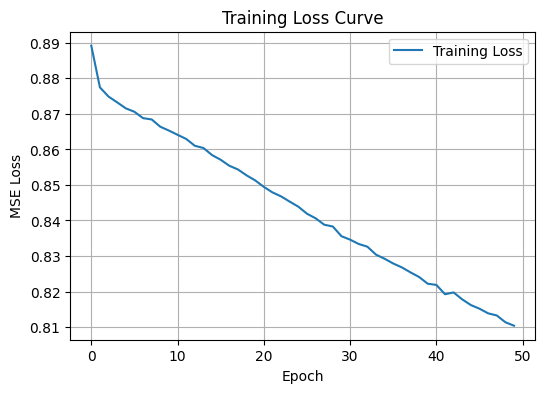

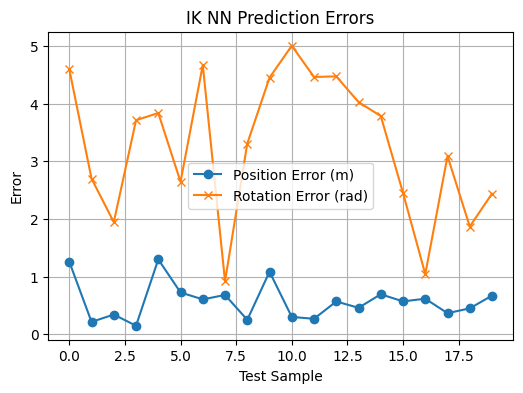

Mean position error: 0.5768 m
Mean rotation error: 3.2730 rad


In [29]:
# --------------------------
# Utility functions
# --------------------------
def rotation_matrix_to_vector(R):
    """Convert rotation matrix to rotation vector (axis-angle)"""
    angle = np.arccos(np.clip((np.trace(R)-1)/2, -1.0, 1.0))
    if np.isclose(angle, 0):
        return np.zeros(3)
    axis = np.array([R[2,1]-R[1,2], R[0,2]-R[2,0], R[1,0]-R[0,1]]) / (2*np.sin(angle))
    return axis * angle

def scale_data(X, Y):
    """Compute mean/std and scale data"""
    X_mean, X_std = X.mean(axis=0), X.std(axis=0)
    Y_mean, Y_std = Y.mean(axis=0), Y.std(axis=0)
    X_scaled = (X - X_mean)/X_std
    Y_scaled = (Y - Y_mean)/Y_std
    return X_scaled, Y_scaled, X_mean, X_std, Y_mean, Y_std

def descale(Y_scaled, Y_mean, Y_std):
    return Y_scaled * Y_std + Y_mean

# --------------------------
# Parameters
# --------------------------
n_samples = 10000
ur5_limits = [
    (-2*np.pi/3, 2*np.pi/3),  # θ1
    (-np.pi, np.pi),          # θ2
    (-2*np.pi/3, 2*np.pi/3),  # θ3
    (-2*np.pi, 2*np.pi),      # θ4
    (-2*np.pi, 2*np.pi),      # θ5
    (-2*np.pi, 2*np.pi)       # θ6
]

# --------------------------
# Generate dataset using FK
# --------------------------
X = []  # 6D pose
Y = []  # joint angles
branches = []  # 0 = elbow-down, 1 = elbow-up

for _ in range(n_samples):
    theta = np.array([np.random.uniform(low, high) for low, high in ur5_limits])
    dq = dq_fk(sn, theta)   # FK function
    M = dq_to_homogeneous(dq)
    
    pos = M[:3, 3]
    rot_vec = rotation_matrix_to_vector(M[:3, :3])
    pose_vec = np.hstack((pos, rot_vec))
    
    X.append(pose_vec)
    Y.append(theta)
    
    # simple heuristic: elbow-up if θ2 < 0
    branch = 1 if theta[1] < 0 else 0
    branches.append(branch)

X = np.array(X)
Y = np.array(Y)
branches = np.array(branches).reshape(-1,1)

# One-hot encode branch
branch_onehot = np.zeros((n_samples,2))
branch_onehot[np.arange(n_samples), branches[:,0]] = 1

# Concatenate branch info to input
X_input = np.hstack((X, branch_onehot))

# Scale
X_scaled, Y_scaled, X_mean, X_std, Y_mean, Y_std = scale_data(X_input, Y)

# --------------------------
# Train neural network
# --------------------------
model = Sequential([
    Dense(128, activation='relu', input_shape=(8,)),  # 6 pose + 2 branch
    Dense(128, activation='relu'),
    Dense(6)  # predict joint angles
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_scaled, Y_scaled, batch_size=32, epochs=50, verbose=1)

# --------------------------
# Plot training loss
# --------------------------
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.legend()
plt.show()

# --------------------------
# Verify predictions
# --------------------------
n_test = 20
pos_errors = []
rot_errors = []

for _ in range(n_test):
    idx = np.random.randint(0, n_samples)
    target_pose = X[idx:idx+1]
    target_branch = branch_onehot[idx:idx+1]
    X_test = np.hstack((target_pose, target_branch))
    X_test_scaled = (X_test - X_mean)/X_std
    
    true_theta = Y[idx]
    
    # predict joint angles
    theta_pred_scaled = model.predict(X_test_scaled, verbose=0)
    theta_pred = descale(theta_pred_scaled, Y_mean, Y_std)[0]
    
    # FK to get predicted pose
    dq_pred = dq_fk(sn, theta_pred)
    M_pred = dq_to_homogeneous(dq_pred)
    
    pos_error = np.linalg.norm(target_pose[0,:3] - M_pred[:3,3])
    R_diff = target_pose[0,3:] - rotation_matrix_to_vector(M_pred[:3,:3])
    rot_error = np.linalg.norm(R_diff)
    
    pos_errors.append(pos_error)
    rot_errors.append(rot_error)

# --------------------------
# Visualize errors
# --------------------------
plt.figure(figsize=(6,4))
plt.plot(pos_errors, label='Position Error (m)', marker='o')
plt.plot(rot_errors, label='Rotation Error (rad)', marker='x')
plt.xlabel('Test Sample')
plt.ylabel('Error')
plt.title('IK NN Prediction Errors')
plt.legend()
plt.grid(True)
plt.show()

print(f"Mean position error: {np.mean(pos_errors):.4f} m")
print(f"Mean rotation error: {np.mean(rot_errors):.4f} rad")